In [ ]:
#libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
print(sqlite3.sqlite_version)

3.50.4


Import SQL File

In [70]:
conn = sqlite3.connect(r"D:\Data Analyst Project Related Material\customer_churn.db")

sql_query = """
SELECT name
FROM sqlite_master
WHERE type = 'table'
"""

tables = pd.read_sql(sql_query, conn)

for table_name in tables["name"]:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)

    globals()[f"df_{table_name}"] = df

    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [71]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(
    r"D:\Data Analyst Project Related Material\customer_churn.db"
)

for table_name in tables["name"]:
    print(f"\nTable Name: {table_name}")

    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)

    print("Columns:")
    print(columns["name"].tolist())

conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [72]:
import os

print(os.path.abspath("customer_churn.db"))


d:\AI AUtomation\customer_churn.db


Data Cleaning

In [73]:
#df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [74]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [7]:
# a. rename column
# b. drop columnn interset and pincode
# c. change data type - dob
# d. data standardization - gernder
# e. fix missing value - country

In [75]:
# rename column
df_db_customer.rename(columns = {'name' : 'customer_value'}, inplace = True)

In [77]:
#b. drop columnn interset and pincode
df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
#df_db_customer.drop(columns= ['interests','pincode'],inplace = True)


,customerid,customer_value,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [78]:
df_db_customer

,customerid,customer_value,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [79]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      21 non-null     str   
 1   customer_value  21 non-null     str   
 2   country         18 non-null     str   
 3   state           21 non-null     str   
 4   gender          21 non-null     str   
 5   dob             21 non-null     str   
 6   interests       4 non-null      str   
 7   pincode         0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [80]:
# c. change data type - dob
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [81]:
# d. data standardization - gernder
#df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

In [82]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [83]:
# e. fix missing value - country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_value,country,state,gender,dob,interests,pincode
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07,NaN,None
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01,NaN,None


In [84]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,NaN,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,NaN,Kathmandu
9,Nepal,Kathmandu


In [85]:
# country and state - unique value pair
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [86]:
df_db_customer[['country']]

,country
0,India
1,India
2,India
3,India
4,India
5,India
6,India
7,India
8,Nepal
9,Nepal


In [87]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [88]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaN,NaN,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaN,NaN,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaN,NaN,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaN,NaN,13.99,790,47


In [89]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [90]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [91]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [92]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [93]:

df_db_support.drop(columns= ['col_1','comment'],inplace = True)

In [94]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      9 non-null      str  
 1   complaint_date  9 non-null      str  
 2   escalations     9 non-null      str  
 3   csat_score      9 non-null      int64
dtypes: int64(1), str(3)
memory usage: 420.0 bytes


In [95]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [96]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [97]:
#3 Feature Engineering and Data Analysis
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34


In [98]:
#create new col using existing col 
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [99]:

df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,41,0


In [100]:
#first fix support table duplicates then merge
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how= 'left' )
    .merge(df_db_support, on = 'customerid', how= 'left' ))

In [101]:
df_db_subscription.shape

(21, 12)

In [102]:
df.shape

(23, 22)

In [103]:
df_db_customer['customerid'].nunique()

21

In [104]:
df_db_subscription['customerid'].nunique()

21

In [105]:
df_db_support['customerid'].nunique()

7

In [106]:
df_db_support['customerid'].size

9

In [107]:
df_db_support['complaint_count']= df_db_support.groupby('customerid')['customerid'].transform('count')

In [108]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [109]:
df_db_support= df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep = 'last')

In [110]:
#merge df
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how= 'left' )
    .merge(df_db_support, on = 'customerid', how= 'left' ))

In [111]:
df.shape

(21, 23)

In [112]:
#Data Analysis

In [113]:
#1. Churn Rate
df.to_csv('exported_churn_data.csv',index=False)

In [114]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_value', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'complaint_count'],
      dtype='str')

In [115]:
df['churn_flag'].mean()

np.float64(0.2857142857142857)

In [116]:
churn_rate = df['churn_flag'].mean()*100
print("Churan Rate = ", round(churn_rate,2),"%")

Churan Rate =  28.57 %


In [117]:
#Retention Rate
retention_rate = 100- churn_rate
print("Retention Rate = ", round(retention_rate,2),"%")

Retention Rate =  71.43 %


In [118]:
#3 CHurn by plan Type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [119]:
# 4 a. Churn by state + sum(revenue) & count of users  -- home work **
# 4 b. Churn by subscription type + sum(revenue) & count of users  -- home work **

In [120]:
# 5. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [122]:
#Homework calculate age work

In [123]:
#6 Average Customer Tenure
#count of days users has used our service: cancellation date else current date
today = pd.Timestamp.today()
df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)
 
avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure), 0)

Avg Tenure (Days) =  1555 0


In [124]:
#7 Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs Lakhs) =", revenue_at_risk)

Revenue at Risk (Rs Lakhs) = 73.94


In [125]:
#8 Escalation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Escalation Rate =", round(escalation_rate,2),"%")

Escalation Rate = 19.05 %


In [126]:
#Average Complaint Rate
avg_complaint = df['complaint_count'].sum()/df['customerid'].nunique()
print("Avg Complaint Per User = ",round(avg_complaint,2))

Avg Complaint Per User =  0.43


In [127]:
##10 Coorelation Escalation vs Churn
df[['escalations','churn_flag']].dropna()

,escalations,churn_flag
1,Y,1
4,Y,1
5,N,0
6,N,1
11,Y,1
13,Y,1
18,N,1


In [128]:
#Correlation Escalation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escalation vs churn is = ", round(correlation,2))

Correlation between escalation vs churn is =  0.77


In [130]:
#11 Churn Score
# 11. Churn risk - create a column using existing col
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')

In [131]:
df[['churn_risk', 'churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [62]:
#Visulization using Matplotlib

In [132]:
df_visual = df.copy()

In [133]:
# 4.1 Monthly Churn Trend (Time Series KPI)
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

cancellation_month
2024-02    1
2024-05    1
2024-09    2
2024-10    1
2024-11    1
Freq: M, dtype: int64

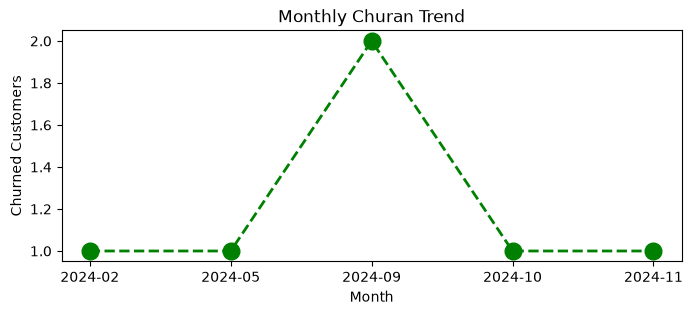

In [134]:
# 4.1 Monthly Churn Trend (Time Series KPI)
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12)
plt.title('Monthly Churan Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

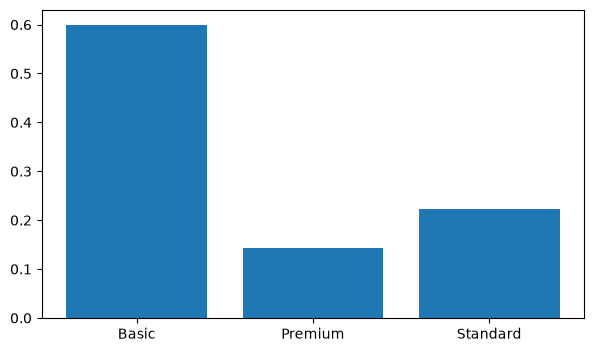

In [ ]:
#4.2 Churn by plan Time
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = ['yellow','purple']
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values)
plt.show()

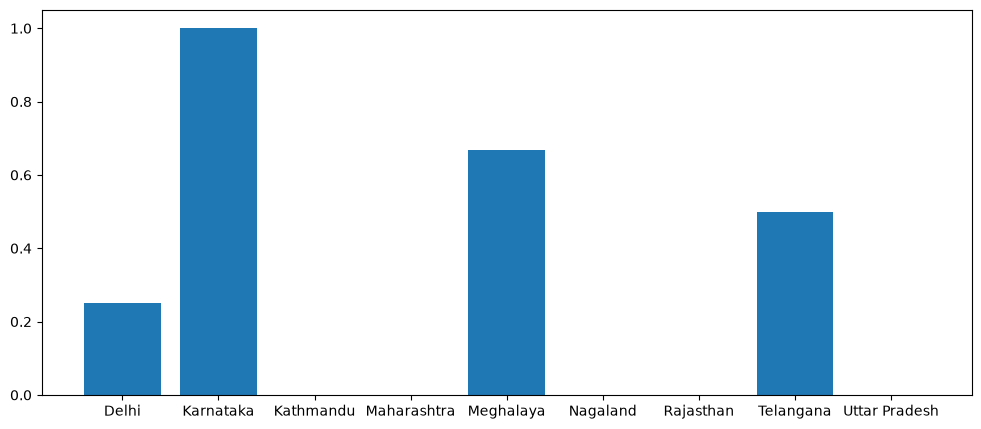

In [140]:
#4.3 Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colors = ['yellow','purple']
plt.figure(figsize=(12,5))
plt.bar(churn_plan.index,churn_plan.values)
plt.show()

In [ ]:
#Visualization using Seaborn

In [141]:
#encoding - convert str to numeric so we can find corr between features 
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_value', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'complaint_count', 'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [145]:
df_visual[['plan_type','contract_type','churn_score', 'churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_risk,escalations
0,Standard,Annual,12,low,0
1,Premium,Annual,91,high,1
2,Basic,Monthly,34,low,0
3,Premium,Annual,8,low,0
4,Standard,Monthly,88,high,1


In [ ]:
#encoding - convert str to numeric so we can find corr between features 
df_encode= df_visual[['plan_type','contract_type','churn_score', 'churn_risk','escalations']].head()
categorical_cols = ['plan_type','contract_type','churn_risk']
for col in categorical_cols:
    df_encode[col] = df_encode[col].astype('category').cat.codes

In [147]:
df_encode.head()

,plan_type,contract_type,churn_score,churn_risk,escalations
0,2,0,12,1,0
1,1,0,91,0,1
2,0,1,34,1,0
3,1,0,8,1,0
4,2,1,88,0,1


<Axes: >

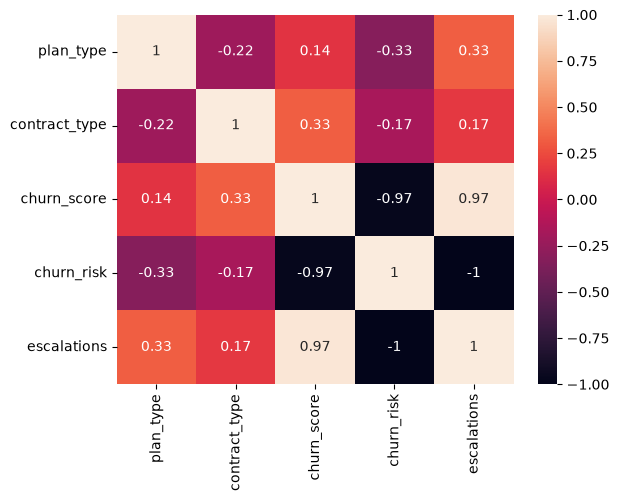

In [149]:
#Heatmap (correlation matrix)
sns.heatmap(df_encode.corr(), annot= True)

In [150]:
df_visual['plan_type'].unique()

<StringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str

In [155]:
#correct method of encoding based on priority 
df_encode= df_visual[['plan_type','contract_type','churn_score', 'churn_risk','escalations']]

order_mapping = {
    'plan_type':['Standard', 'Premium', 'Basic'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low','med','high']
}
categorical_cols = ['plan_type','contract_type','churn_risk']
for col,order in order_mapping.items():
    df_encode[col] = pd.Categorical(df_encode[col].astype('category'),categories=order ,ordered= True).codes

In [156]:
df_visual[['plan_type','contract_type','churn_score', 'churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [157]:
df_encode.head()

,plan_type,contract_type,churn_score,churn_risk,escalations
0,0,1,12,0,0
1,1,1,91,2,1
2,2,0,34,0,0
3,1,1,8,0,0
4,0,0,88,2,1


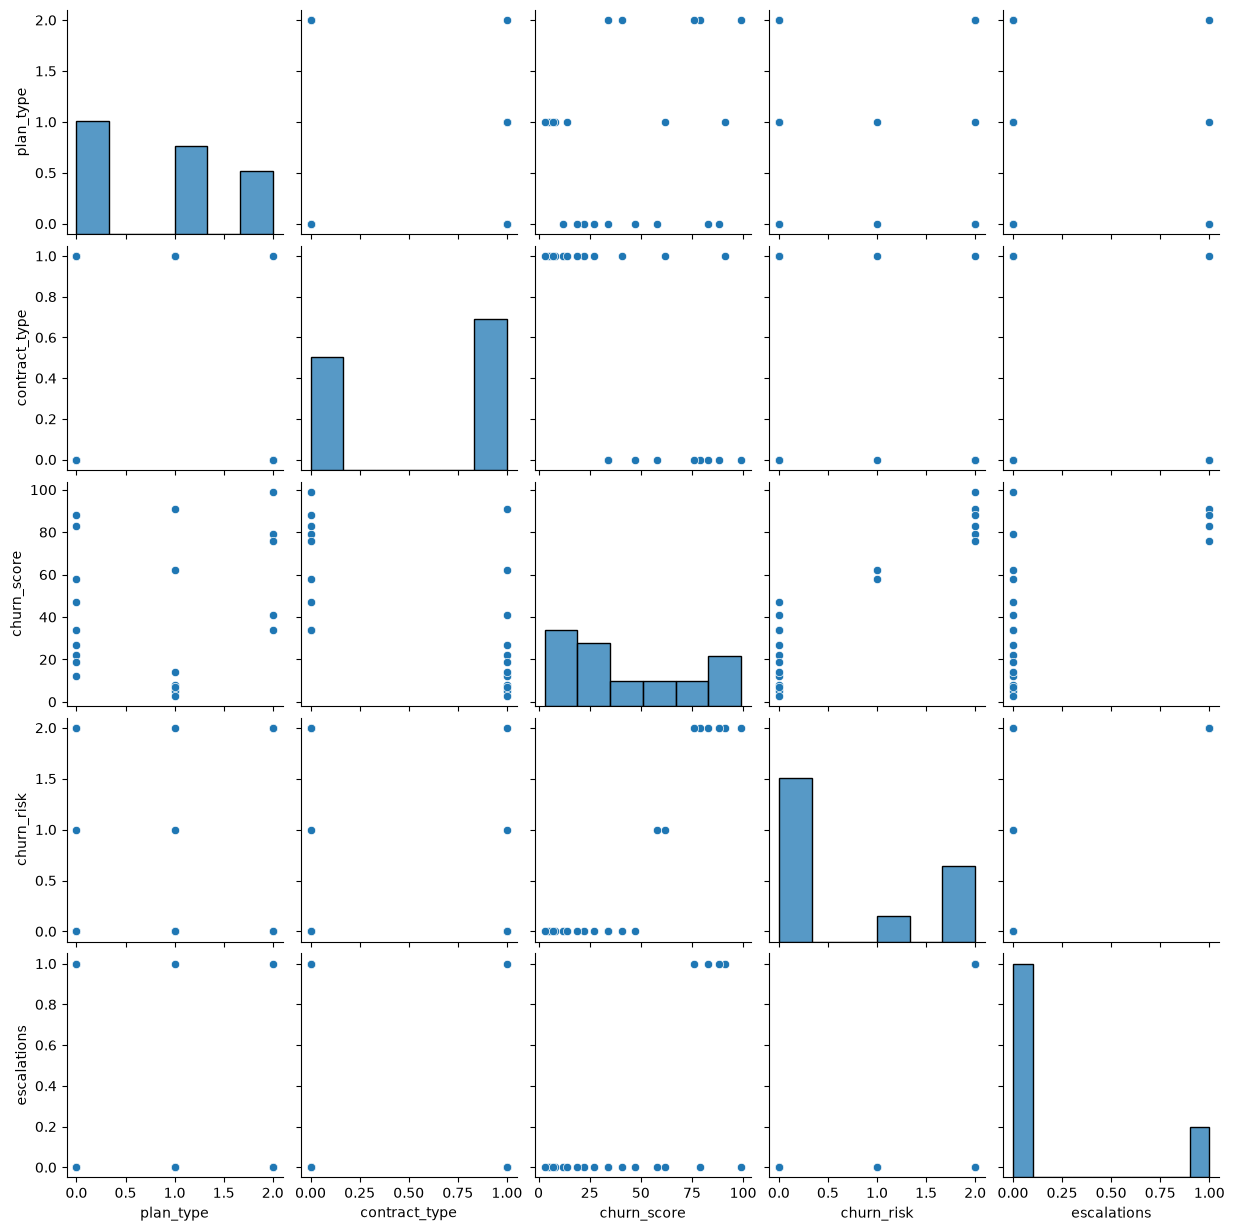

In [158]:
#paiplot
sns.pairplot(df_encode)

In [160]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_value', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'complaint_count', 'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

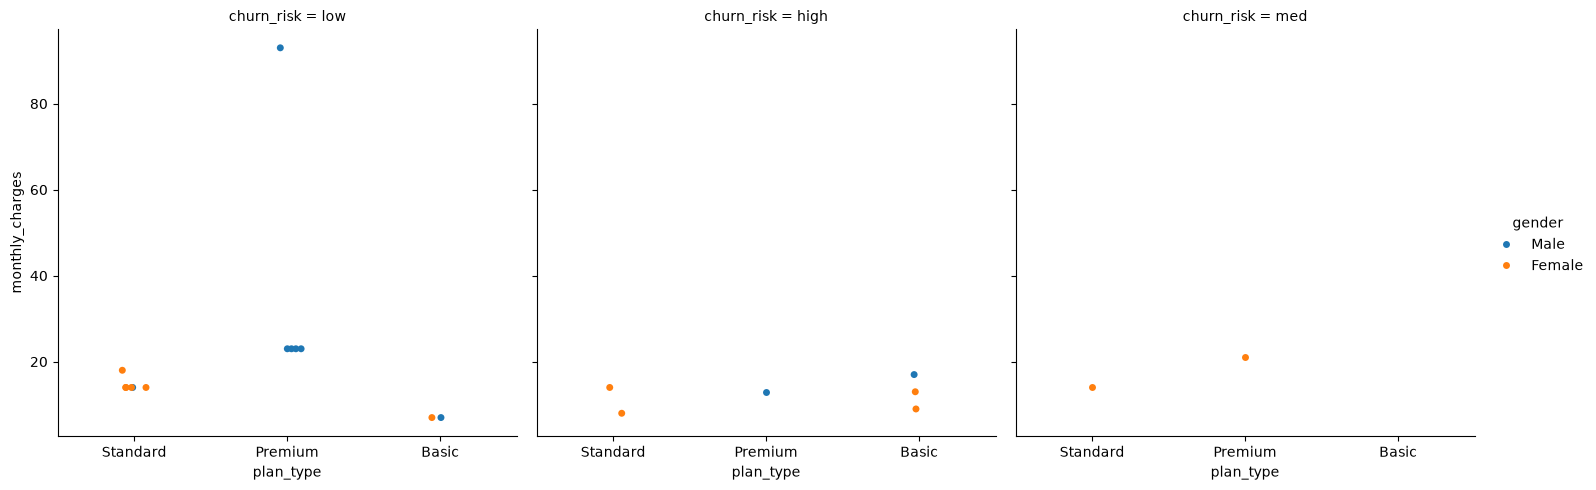

In [164]:
#catplt / Facedgrid plot - multi_dim comparison
sns.catplot(data = df_visual,
    x  = 'plan_type',
    y  = 'monthly_charges',
    hue= 'gender',
    col= 'churn_risk')

In [ ]:
#Pivot Table

In [172]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean').reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [173]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


#Working with SQL in Python (Pandas)

In [ ]:
#create DB in SQL
conn = sqlite3.connect('Test_Database.sqlite')

#Table Details 
conn.execute("Create Table users (first_name TEXT, country TEXT, Budget INTEGER)")

#commit and save

conn.commit()

In [178]:
#insert data

cursor = conn.cursor()
#write sql query to insert the data
cursor.execute(
    """
        INSERT INTO Users VALUES  
            ('Umer','Pakistan','50000'),
            ('Asghar','India','40000'),
            ('Asif','Germany','30000') 
    """
)
conn.commit()
print("Data Inserted Successfully!")


Data Inserted Successfully!


In [190]:
conn = sqlite3.connect('Test_Database.sqlite')
query = """SELECT * FROM Users"""
df_results = pd.read_sql(query, conn)
df_results.head()

,first_name,country,Budget
0,Umer,Pakistan,50000
1,Asghar,India,40000
2,Asif,Germany,30000


In [191]:
# aggregation
query = """
    SELECT country, SUM(budget) as total_budget
    FROM users
    GROUP BY country
"""

df_agg = pd.read_sql(query, conn)
df_agg


,country,total_budget
0,Germany,30000
1,India,40000
2,Pakistan,50000


In [ ]:
#always close the conn with db once the task is over
conn.close()

In [136]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_value', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'complaint_count', 'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [ ]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_value', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='str')